Copyright (c) 2025 Robert Bosch GmbH

SPDX-License-Identifier: AGPL-3.0

# Minimal Working Example (MWE) for two trips

In [2]:
import yaml
import os
import addict

config_path = "configs/nusc/multi_trip.yaml"

with open(config_path) as file:
    configs = yaml.safe_load(file)
configs["file"] = os.path.abspath(config_path)
configs = addict.Dict(configs)

configs.dataset.clip_list = [
    "scene-0367",
    "scene-0313"
]

configs.bev_processing.scene_collection_path = None
configs.optimization.epochs = 2

#Adjust config for MapTR BEV production
configs.train.log = False
configs.train.store_cfg = False
configs.train.store_artefacts = False
configs.train.output_render = False

In [3]:
import train

gaussians, exposure_model, dataset, _ = train.train(configs)

Loading NuScenes tables for version v1.0-trainval...
Loading nuScenes-panoptic...
32 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
34149 panoptic,
Done loading in 28.563 seconds.
Reverse indexing ...
Done reverse indexing in 7.0 seconds.
Loading NuScenes tables for version v1.0-test...
Loading nuScenes-panoptic...
32 category,
8 attribute,
4 visibility,
0 instance,
12 sensor,
1800 calibrated_sensor,
462901 ego_pose,
15 log,
150 scene,
6008 sample,
462901 sample_data,
0 sample_annotation,
4 map,
0 panoptic,
Done loading in 2.796 seconds.
Reverse indexing ...
Done reverse indexing in 0.7 seconds.


Loading data clips:   0%|          | 0/2 [00:00<?, ?it/s]

Loading data from scene scene-0367


Loading data clips:  50%|█████     | 1/2 [00:00<00:00,  4.58it/s]

Loading data from scene scene-0313


Loading data clips: 100%|██████████| 2/2 [00:00<00:00,  2.84it/s]


Drop 0 frames out of 2774 by image exists check
Drop 0 frames out of 2774 by label exists check
Drop 0 lidar out of 777 by lidar exists check
Drop 0 frames out of 2774 by file exists check
Before cutting,  8366806 vertices
After cutting,  1825439 vertices
Number of points at initialisation :  1825439


Training progress: 100%|█████████▉| 5540/5548 [02:33<00:00, 36.07it/s, Loss=0.5698971, hit_num=19692/1825439] 


In [4]:
# Setup
import torch
import numpy as np

MASK_CLASS = 0

pipe = configs.pipeline
device = torch.device(configs["device"] if torch.cuda.is_available() else "cpu")

bg_color_fun = torch.rand if configs.optimization.random_background \
    else (torch.ones if configs.model.white_background else torch.zeros)
bg_color = bg_color_fun(3, dtype=torch.float32, device=device)

bg_label = torch.zeros(6, dtype=torch.float32, device=device) # 6 classes
bg_label[MASK_CLASS] = 1



lidar_key_poses = dataset.lidar2world_all[dataset.lidar_is_keyframe]

In [37]:
from utils.render import render, render_label
import cv2
import maptr_camera

proc_config = configs.bev_processing
pad_width = proc_config.pad_width

key_frame_idx = 25
lidar_pose = torch.tensor(lidar_key_poses[key_frame_idx], dtype=torch.float32)
ref_pose = torch.tensor(dataset.ref_pose, dtype=torch.float32)

# Produce BEVs for MapTR training
cam = maptr_camera.MapTRCamera(lidar_pose, ref_pose, device, bev_h=proc_config.height, bev_w=proc_config.width)
cam = cam.pad_image(pad_width)

# BEV rendering
# label
label_feature = render_label(cam, gaussians, pipe, bg_label)
bev_label, bev_mask = label_feature["render"], label_feature["mask"]
bev_label = np.argmax(bev_label.detach().cpu().numpy(), axis=0)  # (H, W)
bev_mask = bev_mask.cpu().numpy()
bev_mask = bev_mask & (bev_label != MASK_CLASS)
bev_label[~bev_mask] = MASK_CLASS

#image
bev_pkg = render(cam, gaussians, pipe, bg_color)
src_bev_image = bev_pkg["render"]
bev_image = exposure_model(0, src_bev_image)
bev_image = bev_image.permute(1, 2, 0)
bev_image = bev_image.detach().cpu().numpy() * 255
bev_image = cv2.cvtColor(bev_image.astype(np.uint8), cv2.COLOR_RGB2BGRA)
bev_image[~bev_mask] = 0

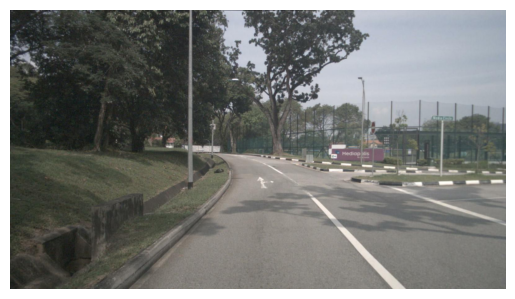

In [38]:
img_key_frame_idx = key_frame_idx
SELECTED_CAM = 0

img_path = [filepath for filepath, cam_idx in zip(dataset.image_filenames_all, dataset.cameras_idx_all) if cam_idx==SELECTED_CAM and "sample" in filepath][img_key_frame_idx]

img_path = os.path.join(configs.dataset.base_dir, img_path)

# show img
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

img = Image.open(img_path)
plt.imshow(np.array(img))
plt.axis('off')
plt.show()

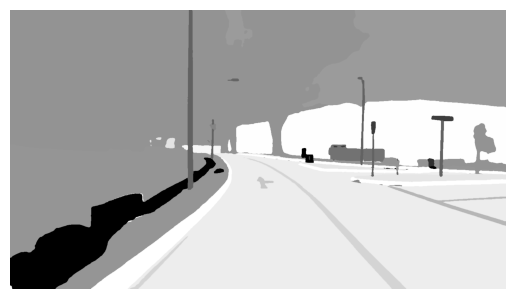

In [39]:
segmentation_path = img_path\
    .replace(configs.dataset.base_dir, configs.dataset.label_dir)\
    .replace(".jpg", ".png")\
    .replace("/CAM", "/seg_CAM")    

# show segmentation
segmentation = np.array(Image.open(segmentation_path))
plt.imshow(segmentation)
plt.axis('off')
plt.show()

In [40]:
import matplotlib.pyplot as plt
from utils.image import render_semantic


def visualize_bev_label(bev_label, figsize=(10, 10)):
    vis_bev_label = render_semantic(bev_label, dataset.filted_color_map)
    plt.figure(figsize=figsize)
    plt.imshow(vis_bev_label)
    plt.axis('off')
    plt.show()

def visualize_bev_img(bev_img, figsize=(10, 10)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(bev_img, cv2.COLOR_BGRA2RGB))
    plt.axis('off')
    plt.show()


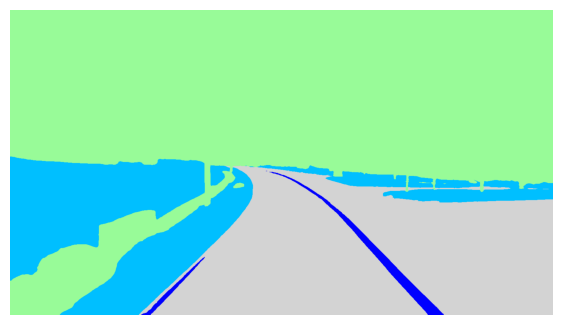

In [41]:
import cv2

remap_seg = np.array(cv2.LUT(segmentation, dataset.label_remaps))
visualize_bev_label(remap_seg, figsize=(7, 7))

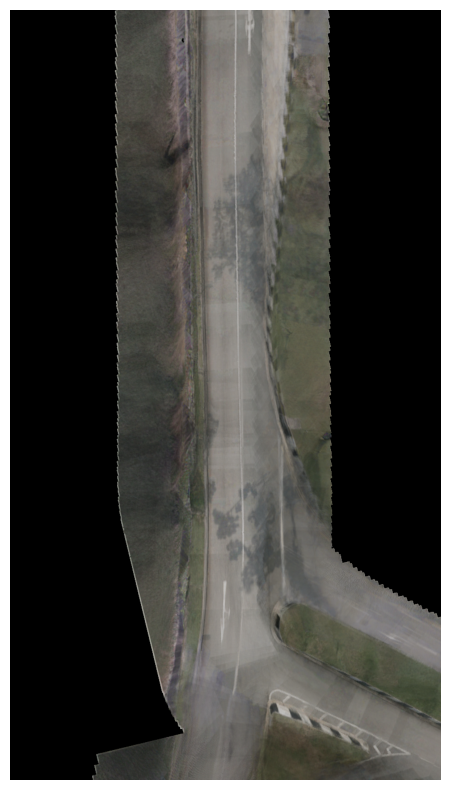

In [42]:
visualize_bev_img(bev_image)

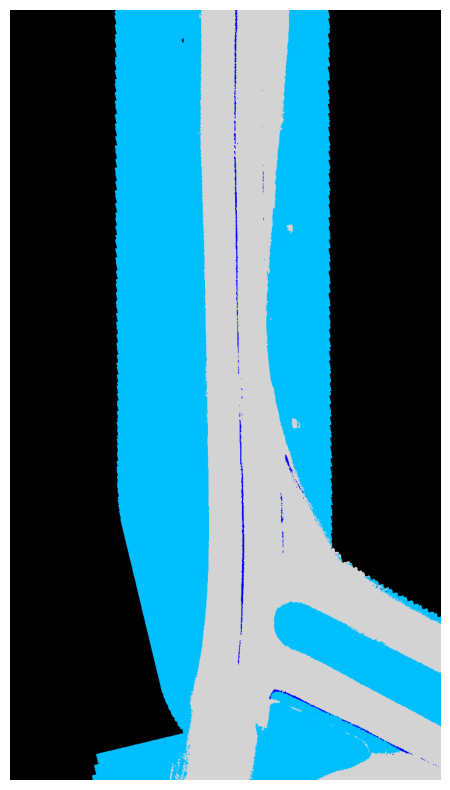

In [43]:
visualize_bev_label(bev_label)

# Postprocessing with CV2

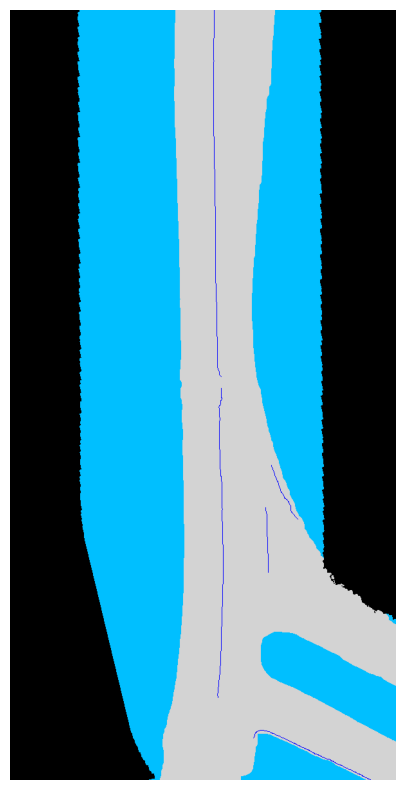

In [44]:
import post_process
import vectorize_mask


bev_label_post, vectors, bev_mask_post = post_process.post_process(bev_label, bev_mask, max_vector_points=20)

for key in vectors.keys():
    new_vectors = []
    is_polygon = key in ["ped_crossing"]
    for vector in vectors[key]:
        new_vectors += vectorize_mask.clip_polyline(vector, bev_label_post.shape[1], bev_label_post.shape[0], pad_width, polygon=is_polygon)
    vectors[key] = new_vectors

bev_label_post = post_process.crop_img(bev_label_post, pad_width)

visualize_bev_label(bev_label_post)

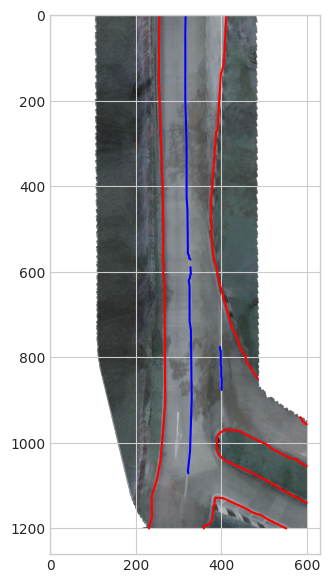

In [45]:
# plot the polygons and lane dividers
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(post_process.crop_img(bev_image, pad_width))
for poly in vectors["ped_crossing"]:
    ax.add_patch(Polygon(poly,color='orange'))

for div in vectors["divider"]:
    ax.plot(div[:, 0], div[:, 1], color='blue')

for bd in vectors["boundary"]:
    ax.plot(bd[:, 0], bd[:, 1], color='red')

ax.set_aspect('equal')

plt.show()

# Border Extraction

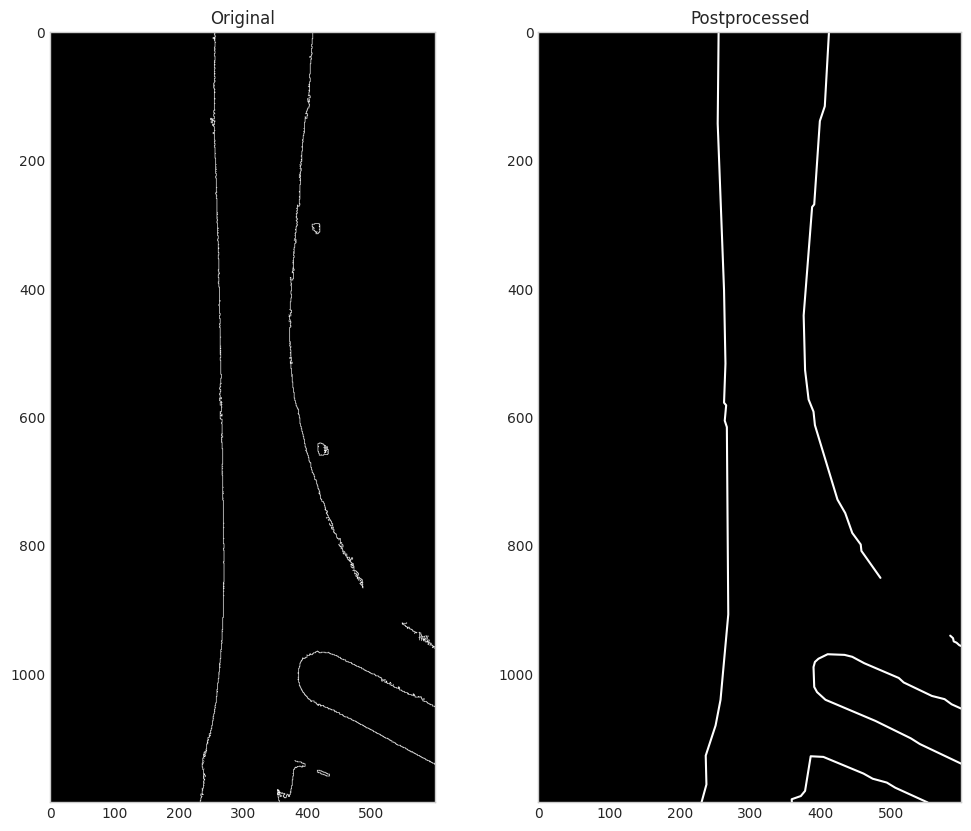

In [46]:
from post_process import extract_border

border_image = extract_border(post_process.crop_img(bev_label, pad_width).astype(np.uint8), 3)

# one figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].imshow(border_image, cmap='gray')
axes[0].set_title("Original")

for bd in vectors["boundary"]:
    # plot in b&w style
    axes[1].plot(bd[:, 0], bd[:, 1], color='white')
# set background color
axes[1].set_facecolor('black')

axes[1].set_xlim(axes[0].get_xlim())
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_title("Postprocessed")
axes[0].grid(False)
axes[1].grid(False)
plt.show()

# Trajectory Plot (Candidate for Centerline)

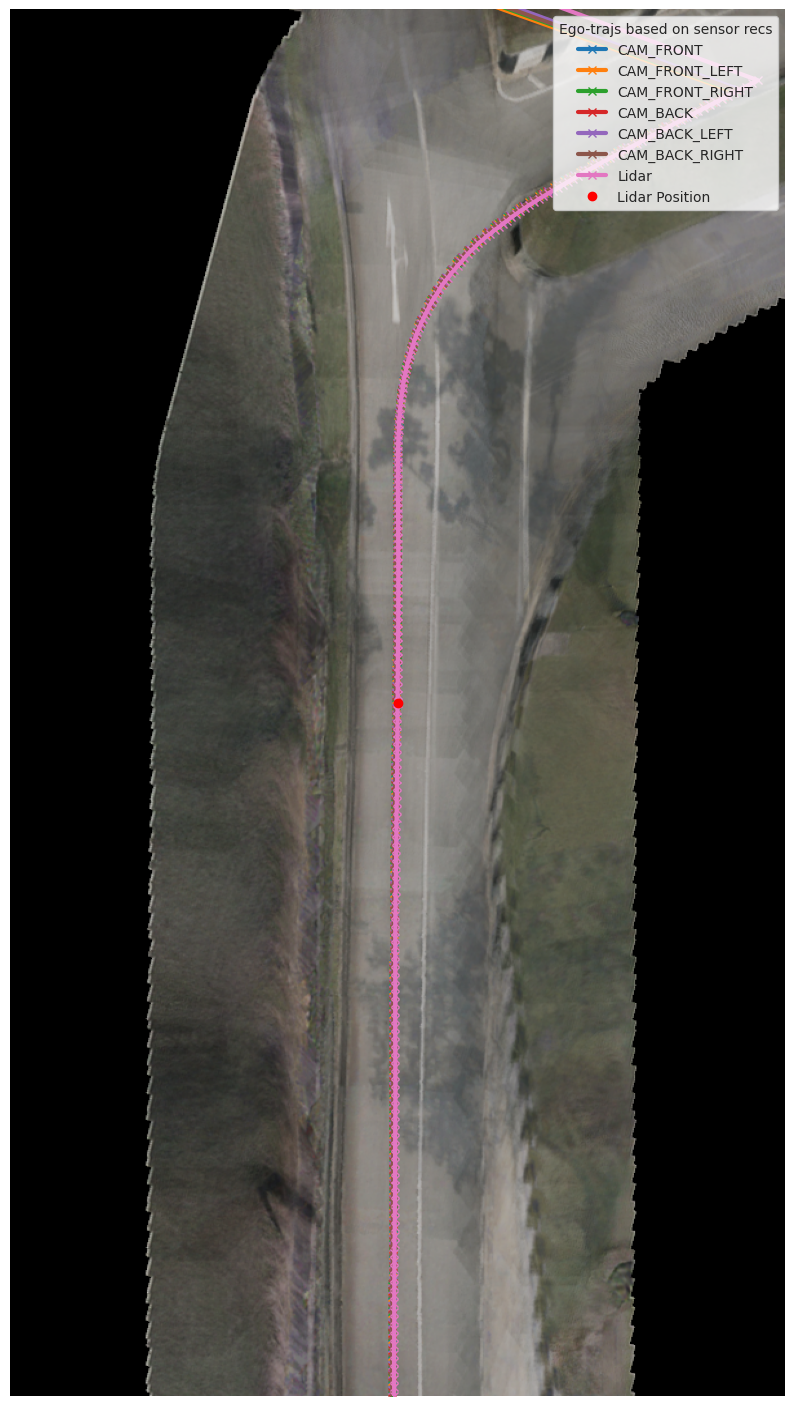

In [47]:
from post_process import ROAD_CLASS, OUTSIDE_CLASS, crop_img



# overlay the label on the image
bev_image_crop = crop_img(bev_image, pad_width)
vis_bev_label_post = render_semantic(bev_label_post, dataset.filted_color_map)
vis_bev_label_post = cv2.cvtColor(vis_bev_label_post, cv2.COLOR_RGB2BGRA)
vis_bev_label_post[bev_label_post == ROAD_CLASS] = 0
vis_bev_label_post[bev_label_post == OUTSIDE_CLASS] = 0

show_rgb = True
show_sem = False

overlay = cv2.addWeighted(bev_image_crop, float(show_rgb), vis_bev_label_post, float(show_sem), 0)
plt.figure(figsize=(10, 20))
extents = [cam.left, cam.right, cam.top, cam.bottom]
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGRA2RGB), extent=extents)



# visualize the camera positions
for cam_name in dataset.camera_names:
    is_correct_cam = [f"__{cam_name}__" in fn for fn in dataset.image_filenames_all]
    traj = dataset.chassis2world_all[is_correct_cam][:, :, 3]
    traj = traj @ cam.world_view_transform.cpu().numpy()
    plt.plot(traj[:, 0], -traj[:, 1], linewidth=3, label=cam_name, marker='x')

# visualize the lidar positions
traj_c = lidar_key_poses[:,:,3]
traj_c = dataset.lidar2world_all[:,:,3]
traj_c = traj_c@cam.world_view_transform.cpu().numpy()
plt.plot(traj_c[:,0], -traj_c[:,1], linewidth=3, label='Lidar', marker='x')


plt.xlim(cam.left, cam.right)
plt.ylim(cam.bottom, cam.top)
plt.plot(0, 0, 'ro', label='Lidar Position')
plt.axis('off')
plt.legend(loc='upper right', frameon=True, facecolor='white', title="Ego-trajs based on sensor recs")
plt.show()

# Animation

In [48]:
# Set the number of total frames for the final GIF/Video

n_frames = 20 # Set to None for all scene frames 

In [49]:
from utils.render import render, render_label
import cv2
import maptr_camera
import imageio

scale = 3

proc_config = configs.bev_processing
pad_width = proc_config.pad_width

marker=None #'o'

plot_line = lambda data, color: ax.plot(data[:,0], data[:,1], color=color, marker=marker, linewidth=scale*1.6, markersize=3*scale, zorder=-1)


# Create list to store images

car_img = Image.open('./assets/car.png')


img_height, img_width = post_process.crop_img(bev_image, pad_width).shape[:2]

# Calculate center position for the car
car_height, car_width = 50, 25
center_x = img_width // 2
center_y = img_height // 2

# Define the extent to place car at center
left = center_x - car_width // 2
right = center_x + car_width // 2
bottom = center_y + car_height // 2
top = center_y - car_height // 2


In [50]:
# Loop through the lidar poses and create the animation

gif_images = []
for lidar_pose_np in dataset.lidar2world_all[:n_frames]:  # just a subset for faster code testing
    lidar_pose = torch.tensor(lidar_pose_np, dtype=torch.float32)
    ref_pose = torch.tensor(dataset.ref_pose, dtype=torch.float32)

    # Produce BEVs for MapTR training
    cam = maptr_camera.MapTRCamera(lidar_pose, ref_pose, device, bev_h=proc_config.height, bev_w=proc_config.width)
    cam = cam.pad_image(pad_width)

    # BEV rendering
    # label
    label_feature = render_label(cam, gaussians, pipe, bg_label)
    bev_label, bev_mask = label_feature["render"], label_feature["mask"]
    bev_label = np.argmax(bev_label.detach().cpu().numpy(), axis=0)  # (H, W)
    bev_mask = bev_mask.cpu().numpy()
    bev_mask = bev_mask & (bev_label != MASK_CLASS)
    bev_label[~bev_mask] = MASK_CLASS

    # image
    bev_pkg = render(cam, gaussians, pipe, bg_color)
    src_bev_image = bev_pkg["render"]
    bev_image = exposure_model(0, src_bev_image)
    bev_image = bev_image.permute(1, 2, 0)
    bev_image = bev_image.detach().cpu().numpy() * 255
    bev_image = cv2.cvtColor(bev_image.astype(np.uint8), cv2.COLOR_RGB2BGRA)
    bev_image[~bev_mask] = 0


    bev_label_post, vectors, bev_mask_post = post_process.post_process(bev_label, bev_mask, max_vector_points=20)

    for key in vectors.keys():
        new_vectors = []
        is_polygon = key in ["ped_crossing"]
        for vector in vectors[key]:
            new_vectors += vectorize_mask.clip_polyline(vector, bev_label_post.shape[1], bev_label_post.shape[0], pad_width, polygon=is_polygon)
        vectors[key] = new_vectors

    
    fig, ax = plt.subplots(figsize=(2*scale, 4*scale))


    cropped_bev_img = post_process.crop_img(bev_image, pad_width)

    ax.imshow(car_img, extent=[left, right, top, bottom], zorder=1)
    ax.imshow(cropped_bev_img, zorder=-2)


    for poly in vectors["ped_crossing"]:
        plot_line(poly, 'blue')

    for div in vectors["divider"]:
        plot_line(div, 'orange')

    for bd in vectors["boundary"]:
        plot_line(bd, 'red')

    #remove axis
    ax.axis('off')

    # switch y axis
    ax.invert_yaxis()

    # Set image extent to match the BEV dimensions
    ax.set_xlim(0, img_width)
    ax.set_ylim(0, img_height)
    plt.tight_layout()

    # Convert matplotlib figure to image array
    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    buf = post_process.crop_img(buf, 15, 30)  # Remove white frame
    gif_images.append(buf)
    
    # Close the figure to free memory
    plt.close(fig)


In [53]:
import cv2

rotate = True

if rotate:
    # Rotate images if needed
    rot_gif_images = [cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE) for frame in gif_images]
else:
    rot_gif_images = gif_images

# Convert gif images to mp4
height, width, layers = rot_gif_images[0].shape

# Define the codec and create VideoWriter object with higher quality
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer = cv2.VideoWriter('scene_bev_animation.mp4', fourcc, 20.0, (width, height))

# Set higher quality parameters (lower compression)
video_writer.set(cv2.VIDEOWRITER_PROP_QUALITY, 100)  # 10%

for frame in rot_gif_images:
    # Convert RGB to BGR for OpenCV
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    video_writer.write(frame_bgr)

video_writer.release()
print("MP4 video saved as 'scene_bev_animation.mp4'")

MP4 video saved as 'scene_bev_animation.mp4'


# Comparison with NuScenes Map

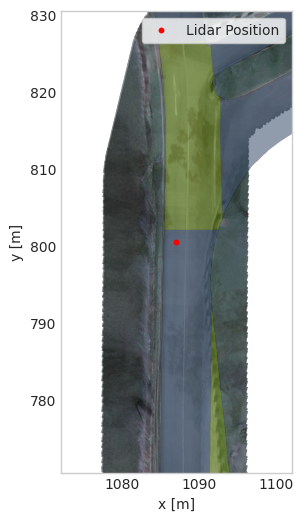

In [52]:
import matplotlib.pyplot as plt
from nuscenes.map_expansion.map_api import NuScenesMap
from pytorch3d.transforms import matrix_to_axis_angle
from matplotlib.colors import LinearSegmentedColormap

# Get scene and map info
scene_name = configs.dataset.clip_list[0]
nusc = dataset.get_nusc_obj(scene_name)
scene = next(s for s in nusc.scene if s['name'] == scene_name)
log = nusc.get('log', scene['log_token'])
nusc_map = NuScenesMap(dataroot=configs.dataset.base_dir, map_name=log['location'])

# Get the idx-th sample in the scene

if hasattr(dataset, "ref_pose_orig"):
    ref_pose_orig = dataset.ref_pose_orig
    lidar2world_all_orig = dataset.lidar2world_all_orig
else:
    ref_pose_orig = dataset.ref_pose
    lidar2world_all_orig = dataset.lidar2world_all

lidar_pose2abs_world = ref_pose_orig @ lidar2world_all_orig[dataset.lidar_is_keyframe][key_frame_idx]
x_center, y_center = lidar_pose2abs_world[:2, 3]
rot_angle = matrix_to_axis_angle(torch.tensor(lidar_pose2abs_world[:3, :3]))[2]* 180 / np.pi

# Set view parameters
bev_h = proc_config.height
bev_w = proc_config.width
x_min, x_max = x_center - bev_w/2, x_center + bev_w/2
y_min, y_max = y_center - bev_h/2, y_center + bev_h/2

# Render map layers
layers = ['drivable_area', 'road_segment', 'lane']

mask = nusc_map.get_map_mask(
    (x_center, y_center, bev_h, bev_w), rot_angle,
    layers,
    (bev_h*20,bev_w*20)
)

alpha = 0.25


plt.figure(figsize=(6, 6))

plt.imshow(bev_image_crop, extent=[x_min, x_max, y_max, y_min])

for i, layer in enumerate(mask):
    rgb = [0, 0, 0]
    rgb[i] = 1
    cmap = LinearSegmentedColormap.from_list('custom', [(0, 0, 0, 0), (*rgb, alpha)])

    # Plot the mask with transparent background
    plt.imshow(layer, extent=[x_min, x_max, y_max, y_min], cmap=cmap)


# # Add ego position and labels
ax = plt.gca()
ax.scatter(x_center, y_center, c='red', label="Lidar Position", s=10)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
# Set axis limits and aspect ratio
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
plt.legend(loc='upper right', frameon=True, facecolor='white')
plt.grid(False)
plt.show()